# 🎭 Eigenfaces Face Recognition - Predicción

**Usa el modelo pre-entrenado para clasificar fotos nuevas.**

⚠️ **Este notebook NO entrena nada. Solo predice usando el modelo guardado en GitHub.**

**Precisión: 93.93% | Reconoce: 14 personas**

## PASO 1: Autorizar Google Drive

In [23]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive montado")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado


## PASO 2: Instalar Dependencias

In [24]:
!pip install mtcnn opencv-python scikit-learn joblib pillow -q
print("✅ Dependencias instaladas")

✅ Dependencias instaladas


## PASO 3: Importar Librerías

In [27]:
import os
import cv2
import numpy as np
from PIL import Image
import joblib
import matplotlib.pyplot as plt
from mtcnn import MTCNN
import warnings
!pip install mtcnn pillow_heif --quiet
!pip install itables --quiet

import os, cv2, numpy as np, math, time, pickle
import matplotlib.pyplot as plt
from PIL import Image
from mtcnn import MTCNN
from tqdm import tqdm
from pillow_heif import register_heif_opener
from IPython import display
from functools import reduce
import polars as pl
import joblib
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

print("✅ Librerías importadas")

✅ Librerías importadas


## PASO 4: Descargar y Cargar Modelo desde GitHub


In [ ]:
import urllib.request
import tempfile

github_usuario = "martinceriotti"

github_repo = "eigenfaces-recognition"

url_modelo = f"https://raw.githubusercontent.com/{github_usuario}/{github_repo}/main/modelos/pca_caras.pkl"
url_nombres = f"https://raw.githubusercontent.com/{github_usuario}/{github_repo}/main/modelos/nombres_unicos.pkl"
url_red_neuronal = f"https://raw.githubusercontent.com/{github_usuario}/{github_repo}/main/modelos/red_neuronal.pkl"

print(f"📥 Descargando modelo desde GitHub...")
print(f"   Usuario: {github_usuario}")
print(f"   Repo: {github_repo}\n")

try:
    # Descargar a archivos temporales
    with tempfile.NamedTemporaryFile(delete=False, suffix='.pkl') as tmp1:
        urllib.request.urlretrieve(url_modelo, tmp1.name)
        modelo = joblib.load(tmp1.name)
        print(f"✅ Modelo descargado")

    with tempfile.NamedTemporaryFile(delete=False, suffix='.pkl') as tmp2:
        urllib.request.urlretrieve(url_nombres, tmp2.name)
        nombres_unicos = joblib.load(tmp2.name)
        print(f"✅ Lista de personas descargada")

    with tempfile.NamedTemporaryFile(delete=False, suffix='.pkl') as tmp_red:
        urllib.request.urlretrieve(url_red_neuronal, tmp_red.name)
        red_data = joblib.load(tmp_red.name)
        # Si es un dict (red.pkl), envolverlo en la clase multiperceptron
        if isinstance(red_data, dict):
            red_neuronal = multiperceptron()
            red_neuronal.red = red_data
        else:
            red_neuronal = red_data
        print(f"✅ Red Neuronal descargada correctamente")  


    print(f"\n✅ MODELO CARGADO EXITOSAMENTE")
    print(f"\n👥 Personas que reconoce: {len(nombres_unicos)}")
    for i, nombre in enumerate(nombres_unicos, 1):
        print(f"   {i:2d}. {nombre}")

    # Inicializar detector de caras
    detector = MTCNN()
    img_size = 64
    print("\n✅ LISTO PARA CLASIFICAR")
    modelo_listo = True

except Exception as e:
    print(f"\n❌ ERROR al descargar el modelo")
    print(f"\n   Posibles causas:")
    print(f"   1. El usuario de GitHub no está correcto")
    print(f"   2. El repositorio no existe")
    print(f"   3. Los archivos .pkl no están en modelos/")
    print(f"\n   Error: {e}")
    modelo_listo = False

📥 Descargando modelo desde GitHub...
   Usuario: martinceriotti
   Repo: eigenfaces-recognition

✅ Modelo descargado
✅ Lista de personas descargada
✅ Red Neuronal descargada correctamente

✅ MODELO CARGADO EXITOSAMENTE

👥 Personas que reconoce: 14
    1. agus
    2. belen
    3. fede
    4. guille
    5. ignacio_paberolis
    6. juani_cacchione
    7. judi
    8. lucia
    9. mariangeles
   10. martin
   11. mati_villanueva
   12. migue
   13. millie
   14. tomas_delbo

✅ LISTO PARA CLASIFICAR


In [28]:

register_heif_opener()
detector = MTCNN()
img_size = 64

class perceptron_plot:
    def __init__(self, X, Y, delay):
        self.activo = X.shape[1] == 2
        self.delay  = delay
        if not self.activo: return
        self.X = X; self.Y = Y
        x1_min, x1_max = np.min(X[:, 0]), np.max(X[:, 0])
        x2_min, x2_max = np.min(X[:, 1]), np.max(X[:, 1])
        self.x1_min = x1_min - 0.1*(x1_max - x1_min)
        self.x1_max = x1_max + 0.1*(x1_max - x1_min)
        self.x2_min = x2_min - 0.1*(x2_max - x2_min)
        self.x2_max = x2_max + 0.1*(x2_max - x2_min)
        self.fig = plt.figure(figsize=(10, 8))
        self.ax  = self.fig.subplots()
        self.ax.set_xlim(self.x1_min, self.x1_max, auto=False)
        self.ax.set_ylim(self.x2_min, self.x2_max, auto=False)

    def graficarVarias(self, W, x0, epoch, error):
        if not self.activo: return
        display.clear_output(wait=True)
        plt.cla()
        self.ax.set_xlim(self.x1_min, self.x1_max)
        self.ax.set_ylim(self.x2_min, self.x2_max)
        plt.title('epoch ' + str(epoch) + '  MSE ' + "{0:.2E}".format(error))
        self.ax.scatter(self.X[:, 0], self.X[:, 1], c=self.Y, s=20)
        for i in range(len(x0)):
            vx2_min = -(W[i, 0]*self.x1_min + x0[i]) / W[i, 1]
            vx2_max = -(W[i, 0]*self.x1_max + x0[i]) / W[i, 1]
            self.ax.plot([self.x1_min, self.x1_max], [vx2_min, vx2_max],
                         linewidth=2, color='red', alpha=0.5)
        display.display(plt.gcf())
        time.sleep(self.delay)


def func_eval(fname, x):
    match fname:
        case "purelin": return x
        case "logsig":
            x = np.clip(x, -500, 500)
            return 1.0 / (1.0 + math.exp(-x))
        case "tansig":
            x = np.clip(x, -500, 500)
            return 2.0 / (1.0 + math.exp(-2.0*x)) - 1.0

def deriv_eval(fname, y):
    match fname:
        case "purelin": return 1.0
        case "logsig":  return y*(1.0 - y)
        case "tansig":  return 1.0 - y*y

func_eval_vec  = np.vectorize(func_eval)
deriv_eval_vec = np.vectorize(deriv_eval)


class multiperceptron(object):

    def _red_init(self, semilla):
        niveles = self.red['arq']['layers_qty']
        np.random.seed(semilla)
        for i in range(niveles):
            nivel = {
                'id': i, 'last': (i == (niveles-1)),
                'size': self.red["arq"]["layers_size"][i],
                'func': self.red["arq"]["layers_func"][i]
            }
            entrada_size = (self.red['arq']['input_size'] if i == 0
                            else self.red['arq']['layers_size'][i-1])
            salida_size  = nivel['size']
            nivel['W']    = np.random.uniform(-0.5, 0.5, [salida_size, entrada_size])
            nivel['w0']   = np.random.uniform(-0.5, 0.5, [salida_size, 1])
            nivel['W_m']  = np.zeros([salida_size, entrada_size])
            nivel['w0_m'] = np.zeros([salida_size, 1])
            self.red['layer'].append(nivel)

    def __init__(self):
        self.data = dict(); self.red = dict(); self.carpeta = ""

    def inicializar(self, df, campos, clase, hidden_layers_sizes, layers_func, semilla, carpeta):
        self.data['X'] = np.array(df.select(campos))
        X_mean         = self.data['X'].mean(axis=0)
        X_sd           = self.data['X'].std(axis=0)
        X_sd[X_sd == 0] = 1.0   # evitar división por cero
        self.data['X'] = (self.data['X'] - X_mean) / X_sd

        label               = df.select(clase)
        self.data['Ylabel'] = np.array(label).reshape(len(label))

        col_originales = df.columns
        self.data['Y'] = np.array(df.to_dummies(clase).drop(col_originales, strict=False))
        col_dummies    = sorted(list(set(df.to_dummies(clase).columns) - set(col_originales)))
        clases_orig    = reduce(lambda acc, x: acc + [x[(len(clase)+1):]], col_dummies, [])

        tamanos = hidden_layers_sizes + [self.data['Y'].shape[1]]
        self.red['arq'] = {
            'input_size'   : self.data['X'].shape[1],
            'input_mean'   : X_mean,
            'input_sd'     : X_sd,
            'output_values': clases_orig,
            'layers_qty'   : len(tamanos),
            'layers_size'  : tamanos,
            'layers_func'  : layers_func,
        }
        self.red['work']  = {'epoch': 0, 'MSE': float('inf'), 'train_error_rate': float('inf')}
        self.red['layer'] = []
        self._red_init(semilla)
        self.carpeta = carpeta
        os.makedirs(self.carpeta, exist_ok=True)
        with open(self.carpeta + "/data.pkl", 'wb') as f: pickle.dump(self.data, f)
        with open(self.carpeta + "/red.pkl",  'wb') as f: pickle.dump(self.red,  f)

    def entrenar(self, epoch_limit, MSE_umbral, learning_rate, lr_momento, save_frequency, retomar=True):
        if retomar:
            with open(self.carpeta + "/data.pkl", 'rb') as f: self.data = pickle.load(f)
            with open(self.carpeta + "/red.pkl",  'rb') as f: self.red  = pickle.load(f)

        epoch   = self.red['work']['epoch']
        MSE     = self.red['work']['MSE']
        niveles = self.red["arq"]["layers_qty"]
        Xfilas  = self.data['X'].shape[0]
        grafico = perceptron_plot(X=self.data['X'], Y=self.data['Ylabel'], delay=0.1)

        while (MSE > MSE_umbral) and (epoch < epoch_limit):
            epoch += 1
            for fila in range(Xfilas):
                x      = self.data['X'][fila:fila+1, :]
                clase  = self.data['Y'][fila:fila+1, :]
                entrada = x.T
                vsalida = [0] * niveles
                for i in range(niveles):
                    estimulos  = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
                    vsalida[i] = func_eval_vec(self.red['layer'][i]['func'], estimulos)
                    entrada    = vsalida[i]
                verror = [0] * (niveles + 1)
                verror[niveles] = clase.T - vsalida[niveles-1]
                i = niveles - 1
                verror[i] = verror[i+1] * deriv_eval_vec(self.red['layer'][i]['func'], vsalida[i])
                for i in reversed(range(niveles-1)):
                    verror[i] = (deriv_eval_vec(self.red['layer'][i]['func'], vsalida[i])
                                 * (self.red['layer'][i+1]['W'].T @ verror[i+1]))
                entrada = x.T
                for i in range(niveles):
                    self.red['layer'][i]['W_m']  = (learning_rate * (verror[i] @ entrada.T)
                                                    + lr_momento * self.red['layer'][i]['W_m'])
                    self.red['layer'][i]['w0_m'] = (learning_rate * verror[i]
                                                    + lr_momento * self.red['layer'][i]['w0_m'])
                    self.red['layer'][i]['W']  += self.red['layer'][i]['W_m']
                    self.red['layer'][i]['w0'] += self.red['layer'][i]['w0_m']
                    entrada = vsalida[i]

            entrada = self.data['X'].T
            for i in range(niveles):
                estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
                salida    = func_eval_vec(self.red['layer'][i]['func'], estimulos)
                entrada   = salida
            MSE = np.mean((self.data['Y'].T - salida)**2)

            if (epoch % save_frequency == 0) or (MSE <= MSE_umbral) or (epoch >= epoch_limit):
                grafico.graficarVarias(self.red['layer'][0]['W'],
                                       self.red['layer'][0]['w0'].T[0], epoch, MSE)
                self.red['work']['epoch'] = epoch
                self.red['work']['MSE']   = MSE
                prediccion = np.argmax(salida.T, axis=1)
                out        = np.array(self.red["arq"]['output_values'])
                self.red["work"]['train_error_rate'] = np.mean(self.data['Ylabel'] != out[prediccion])
                with open(self.carpeta + "/red.pkl", 'wb') as f: pickle.dump(self.red, f)
                print(f"  epoch {epoch:4d} | MSE {MSE:.5f} | error_rate {self.red['work']['train_error_rate']:.2%}")

        return (epoch, MSE, self.red['work']['train_error_rate'])

    def predecir_faces(self, X_new_pca, verbose=True):
        niveles = self.red['arq']['layers_qty']
        X_std   = (X_new_pca - self.red['arq']['input_mean']) / self.red['arq']['input_sd']
        entrada = X_std.T
        for i in range(niveles):
            estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
            salida    = func_eval_vec(self.red['layer'][i]['func'], estimulos)
            entrada   = salida
        pred_idx   = np.argmax(salida.T, axis=1)
        confianzas = np.max(salida.T, axis=1)
        out        = np.array(self.red['arq']['output_values'])
        if verbose:
            print("\n── Ranking de confianzas ──")
            scores = salida.T[0]
            for idx in np.argsort(scores)[::-1]:
                barra = "█" * int(abs(scores[idx]) * 20)
                print(f"  {out[idx]:20s} {scores[idx]:+.4f}  {barra}")
            print()
        return out[pred_idx], confianzas

    def cargar_modelo(self, carpeta):
        self.carpeta = carpeta
        with open(self.carpeta + "/red.pkl", 'rb') as f: self.red = pickle.load(f)
        return (self.red['work']['epoch'], self.red['work']['MSE'], self.red['work']['train_error_rate'])

## PASO 5: Crear Carpeta para Fotos

In [29]:
if modelo_listo:
    ruta_fotos = '/content/drive/MyDrive/Fotos_para_clasificar'
    os.makedirs(ruta_fotos, exist_ok=True)

    print(f"📁 Carpeta de fotos: {ruta_fotos}")
    print(f"\n✅ Sube tus fotos a esta carpeta en Google Drive")
    print(f"   Formatos: JPG, PNG, HEIC")

📁 Carpeta de fotos: /content/drive/MyDrive/Fotos_para_clasificar

✅ Sube tus fotos a esta carpeta en Google Drive
   Formatos: JPG, PNG, HEIC


## PASO 6: Función de Predicción

In [ ]:
if modelo_listo:
    def _recortar_cara_con_margen(img_arr, box):
        """Recorte con margen del 20% — idéntico al usado en entrenamiento."""
        x, y, w, h = box
        margen = int(0.2 * min(w, h))
        x1 = max(0, x - margen)
        y1 = max(0, y - margen)
        x2 = min(img_arr.shape[1], x + w + margen)
        y2 = min(img_arr.shape[0], y + h + margen)
        return img_arr[y1:y2, x1:x2]

    def identificar_cara(ruta_foto, mostrar=True):
        """
        Identifica quién es en una foto.
        Pipeline de imagen idéntico al usado en entrenamiento.
        """
        try:
            # Cargar imagen con PIL (igual que entrenamiento)
            img_pil = Image.open(ruta_foto).convert('RGB')
            img_rgb = np.array(img_pil)

            # Detectar cara — sin resize previo (igual que entrenamiento)
            res = detector.detect_faces(img_rgb)
            if not res:
                return {'error': 'No se detectó cara en la imagen'}

            # Usar primera detección (igual que entrenamiento)
            face = _recortar_cara_con_margen(img_rgb, res[0]['box'])

            # Grises + resize (igual que entrenamiento)
            face_gray = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)
            face_resized = cv2.resize(face_gray, (img_size, img_size))

            # Normalizar y proyectar (igual que entrenamiento)
            face_vector = face_resized.flatten() / 255.0
            face_pca = modelo.transform(face_vector.reshape(1, -1))

            # Predicción con Red Neuronal
            nombres_pred, confianzas_pred = red_neuronal.predecir_faces(face_pca, verbose=False)
            nombre = nombres_pred[0]
            confianza = float(confianzas_pred[0])

            # Obtener scores reales de todas las neuronas de salida
            niveles = red_neuronal.red['arq']['layers_qty']
            X_std = (face_pca - red_neuronal.red['arq']['input_mean']) / red_neuronal.red['arq']['input_sd']
            entrada = X_std.T
            for i in range(niveles):
                estimulos = red_neuronal.red['layer'][i]['W'] @ entrada + red_neuronal.red['layer'][i]['w0']
                salida = func_eval_vec(red_neuronal.red['layer'][i]['func'], estimulos)
                entrada = salida
            scores = salida.T[0]
            out_names = red_neuronal.red['arq']['output_values']
            probabilidades = dict(zip(out_names, scores))

            # Visualizar
            if mostrar:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

                ax1.imshow(face_gray, cmap='gray')
                ax1.set_title(f"Identificado: {nombre.upper()}\nConfianza: {confianza:.1%}",
                             fontsize=14, fontweight='bold')
                ax1.axis('off')

                probs_sorted = sorted(probabilidades.items(),
                                    key=lambda x: x[1], reverse=True)[:5]
                nombres_top = [p[0] for p in probs_sorted]
                vals_top = [p[1] for p in probs_sorted]

                colors = ['#2ecc71' if n == nombre else '#95a5a6' for n in nombres_top]

                ax2.barh(nombres_top, vals_top, color=colors)
                ax2.set_xlabel('Probabilidad')
                ax2.set_title('Top 5 Predicciones', fontsize=12, fontweight='bold')
                ax2.set_xlim([0, 1])

                for i, v in enumerate(vals_top):
                    ax2.text(v + 0.02, i, f'{v:.1%}', va='center')

                plt.tight_layout()
                plt.show()

            return {
                'nombre': nombre,
                'confianza': float(confianza),
                'probabilidades': {n: float(p) for n, p in zip(nombres_unicos, probabilidades)}
            }

        except Exception as e:
            return {'error': str(e)}

    print("✅ Función de predicción lista")

✅ Función de predicción lista


## PASO 7: Clasificar UNA Foto

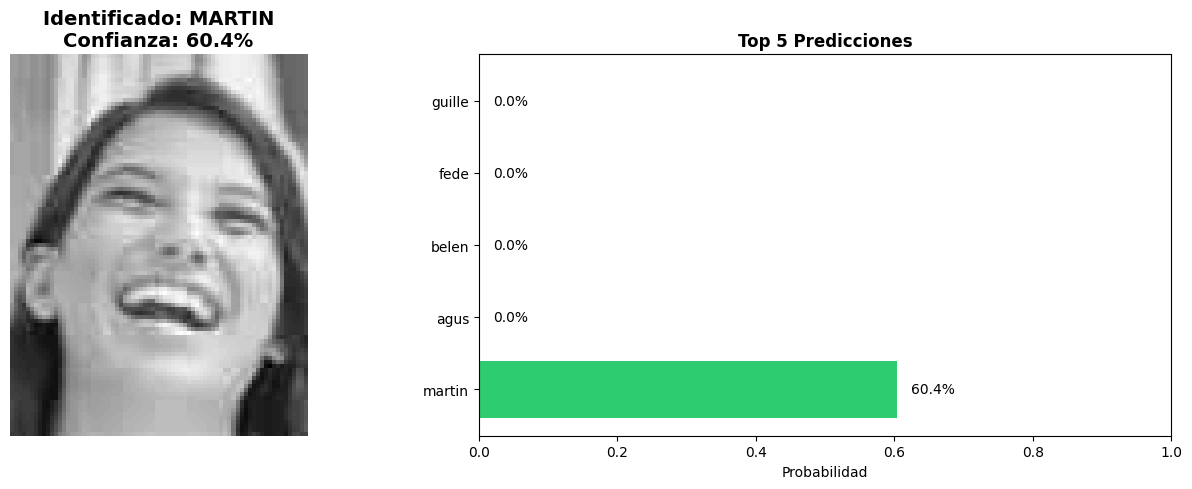


✅ RESULTADO:
   Persona: MARTIN
   Confianza: 60.4%


In [31]:
if modelo_listo:
    # 🔧 EDITA ESTA RUTA (la foto debe estar en tu Google Drive):
    ruta_foto = '/content/drive/MyDrive/Fotos_para_clasificar/Fondo Mision CORA.jpg'

    resultado = identificar_cara(ruta_foto, mostrar=True)

    if 'error' not in resultado:
        print(f"\n✅ RESULTADO:")
        print(f"   Persona: {resultado['nombre'].upper()}")
        print(f"   Confianza: {resultado['confianza']:.1%}")
    else:
        print(f"❌ Error: {resultado['error']}")

## PASO 8: Clasificar TODA una Carpeta

In [ ]:
if modelo_listo:
    import json

    ruta_carpeta = '/content/drive/MyDrive/Fotos_para_clasificar'
    resultados = {}

    print(f"🔄 Clasificando fotos...\n")

    for foto in sorted(os.listdir(ruta_carpeta)):
        if not foto.lower().endswith(('.jpg', '.jpeg', '.png', '.heic')):
            continue

        ruta_completa = os.path.join(ruta_carpeta, foto)
        print(f"Procesando: {foto:<40}", end=' ', flush=True)

        resultado = identificar_cara(ruta_completa, mostrar=False)

        if 'error' not in resultado:
            resultados[foto] = {
                'nombre': resultado['nombre'],
                'confianza': resultado['confianza']
            }
            print(f"✅ {resultado['nombre']:<25} ({resultado['confianza']:.1%})")
        else:
            print(f"❌ {resultado['error'][:40]}")

    # Mostrar resumen
    print(f"\n📊 RESUMEN:")
    print(f"Total clasificadas: {len(resultados)}")

    # Por persona
    personas = {}
    for info in resultados.values():
        nombre = info['nombre']
        personas[nombre] = personas.get(nombre, 0) + 1

    print(f"\nPor persona:")
    for nombre, count in sorted(personas.items(), key=lambda x: x[1], reverse=True):
        print(f"   {nombre:<30} {count:>3} fotos")

    # Guardar resultados
    ruta_salida = os.path.join(ruta_carpeta, 'resultados.json')
    with open(ruta_salida, 'w') as f:
        json.dump(resultados, f, indent=2, ensure_ascii=False)

    print(f"\n✅ Resultados guardados: {ruta_salida}")

🔄 Clasificando fotos...

Procesando: Fondo Mision CORA.jpg                    ✅ martin                    (60.4%)

📊 RESUMEN:
Total clasificadas: 1

Por persona:
   martin                           1 fotos

✅ Resultados guardados: /content/drive/MyDrive/Fotos_para_clasificar/resultados.json


---

## 📋 Resumen

✅ **Listo para usar el modelo pre-entrenado desde GitHub**

1. **PASO 4:** Edita solo tu usuario de GitHub
2. **PASO 7:** Clasifica una foto
3. **PASO 8:** Clasifica una carpeta completa

**Sin entrenar nada. Solo predicción.**